# Churn model: can risk ranking support intervention?

Business question: which model ranks future inactivity usefully, and how much of the event burden is captured in a constrained top-decile list?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
with (ARTIFACTS / "results.json").open() as handle:
    results = json.load(handle)

def table(name, n=8):
    frame = pd.read_csv(ARTIFACTS / "tables" / name)
    display(frame.head(n))
    return frame

def figure(name):
    png = ARTIFACTS / "figures" / f"{name}.png"
    svg = ARTIFACTS / "figures" / f"{name}.svg"
    assert png.exists() and svg.exists(), f"missing paired figure outputs for {name}"
    assert "<svg" in svg.read_text(encoding="utf-8")[:1000]
    display(Image(filename=str(png), width=640))
    return png, svg


,model,brier,roc_auc,pr_auc,lift_at_10pct,capture_at_10pct,precision_at_10pct
0,rule_baseline,0.157791,0.500000,0.196112,0.995482,0.099565,0.195226
1,regularized_logistic,0.133494,0.751840,0.439409,2.673457,0.267391,0.524297
2,hist_gradient_boosting,0.132964,0.750107,0.434812,2.669110,0.266957,0.523444


,target_fraction,customers,event_rate,precision,capture,lift
0,0.1,1173,0.524297,0.524297,0.267391,2.673457
1,0.2,2346,0.496164,0.496164,0.506087,2.530003
2,0.3,3519,0.407218,0.407218,0.623043,2.076457


,bin,predicted_rate,observed_rate,customers
0,"(-0.001, 0.1]",0.081373,0.070959,3650
1,"(0.1, 0.2]",0.138749,0.126063,4117
2,"(0.2, 0.3]",0.245358,0.210826,1404
3,"(0.3, 0.4]",0.347072,0.397421,853
4,"(0.4, 0.5]",0.447113,0.514630,581
5,"(0.5, 0.6]",0.550504,0.513120,686
6,"(0.6, 0.7]",0.636052,0.537931,435
7,"(0.7, 0.8]",0.700460,1.000000,2


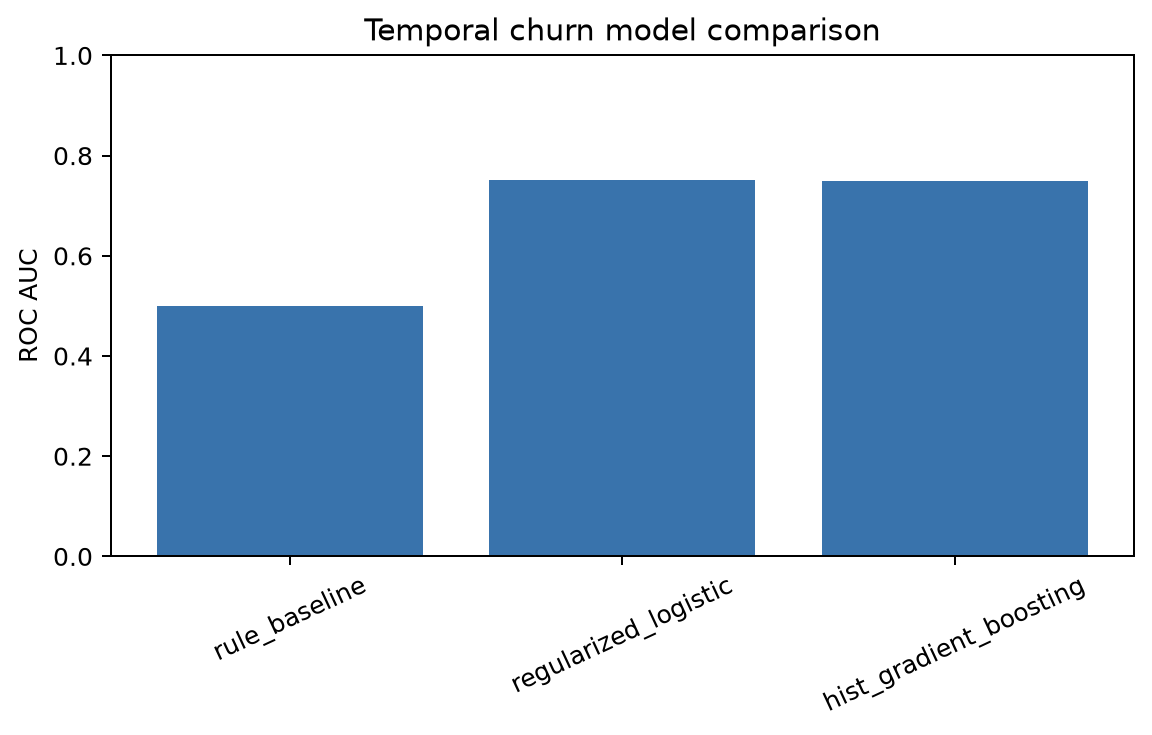

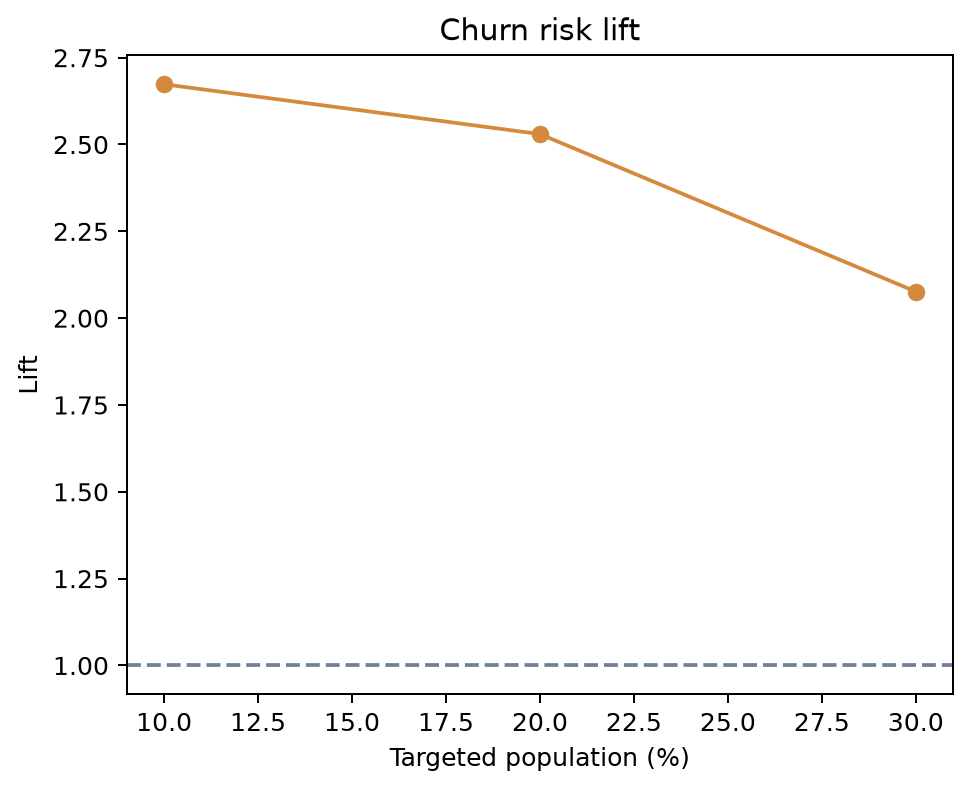

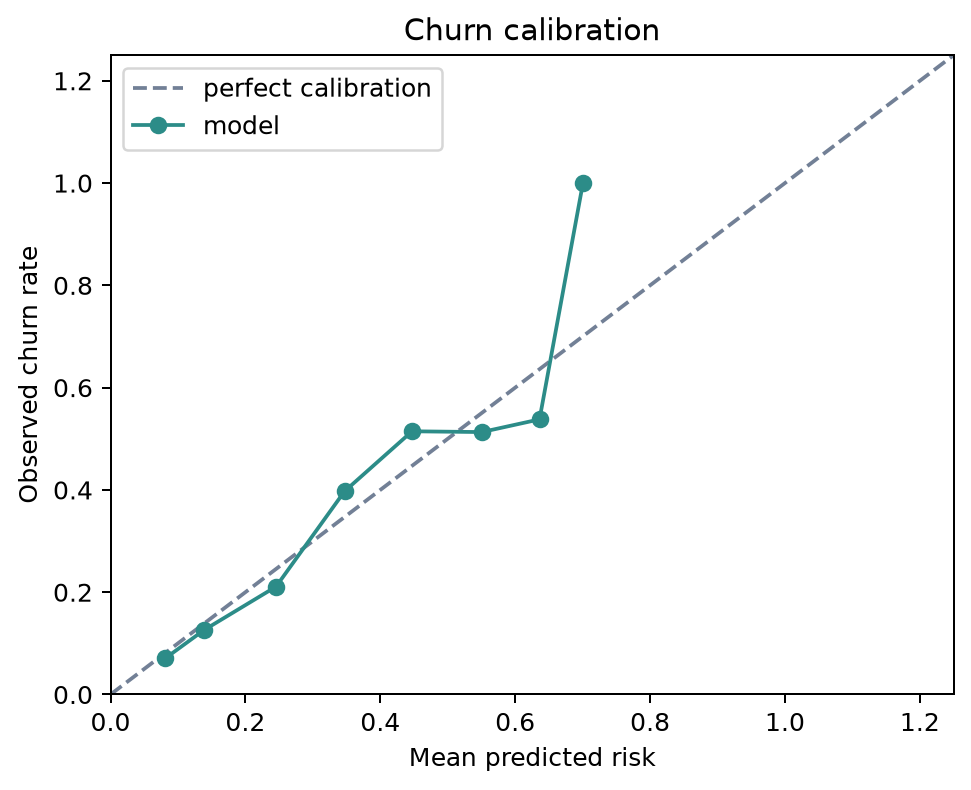

{'selected_model': 'regularized_logistic', 'brier': 0.13349407538542232, 'roc_auc': 0.7518396174208186, 'pr_auc': 0.4394085252804957, 'lift_at_10pct': 2.6734571333259205, 'capture_at_10pct': 0.2673913043478261, 'precision_at_10pct': 0.5242966751918159, 'claim_scope': 'Predictive association on a later temporal holdout, not causal effect.'}


In [2]:
comparison = table('churn_model_comparison.csv', n=12)
lift = table('churn_lift.csv', n=12)
calibration = table('churn_calibration.csv', n=12)
figure('churn_model_comparison')
figure('churn_lift')
figure('churn_calibration')
print(results['churn_model'])

In [3]:
selected = results['churn_model']['selected_model']
row = comparison.loc[comparison['model'].eq(selected)].iloc[0]
print(f"Evidence: selected model={selected!r}; top-decile lift={row['lift_at_10pct']:.3f}; capture={row['capture_at_10pct']:.3f}.")
print('Decision: use the ranking for capacity-aware outreach only after checking calibration, drift, and intervention economics.')

Evidence: selected model='regularized_logistic'; top-decile lift=2.673; capture=0.267.
Decision: use the ranking for capacity-aware outreach only after checking calibration, drift, and intervention economics.


**Uncertainty and scope.** Uncertainty: predictive ranking is not a treatment effect. Performance is evaluation-sample evidence and may drift when customer behaviour or policy changes.

**Decision framing.** Treat the generated artifacts as an auditable working read: inspect the source table, check assumptions, and validate the proposed action with an appropriate follow-up measurement.